In [1]:
# (1) 첨부된 code에서 Q-Learning이 어떻게 적용되었는지 정리해보세요!
# (2) 코드에서 gamma 값을 0.5 또는 0.99로 바꾸어 실행해보고, gamma 값을 다르게 설정하면 Q-matrix가 어떻게 변하는지 비교하여 정리해보세요!

### 🚀 Q-Learning 적용 방식 정리

#### **1️⃣ Q-Learning 개념**
- **Q-Learning**은 **강화 학습(탐색 + 학습) 기반 알고리즘**으로, 
  최적의 행동 정책을 학습하는 방식이다.
- 환경(`state`)에서 특정 행동(`action`)을 수행했을 때 **최적의 보상을 받는 방향으로 학습**함.

---

#### **2️⃣ 코드에서 Q-Learning 적용 과정** <Br>
**1. Q-테이블 초기화**
- `q_matrix = np.zeros((4,5))`  
- 4개 state × 5개 action에 대한 Q-값을 저장하는 행렬 (초기에는 0)

**2. Reward Matrix & Transition Matrix 정의**
- `reward` 행렬: **각 state에서 특정 action을 수행했을 때의 보상**
- `transition_matrix`: **현재 state에서 action을 했을 때 이동할 다음 state**

**3. Q-Learning 알고리즘 실행** <Br>
  *   1️. **초기 상태 설정 (`start_state = 0`)**  
  *  2️. **목표 상태(`state 3`) 도달할 때까지 반복**
  *  3️. **랜덤하게 행동 선택 (`action = random.choice(valid_action[current_state])`)**  
  *  4️. **다음 상태(`next_state = transition_matrix[current_state][action]`) 결정**  
  *  5️. **최적의 Q-값 업데이트**
      \[
      Q(s, a) \leftarrow R(s, a) + \gamma \max Q(s', a')
      \]
  *  6️. **Q-테이블 갱신 (`q_matrix[current_state][action] = q_state`)**  
  *  7️. **목표 상태 도달 시 종료**

✅ **결과적으로 `q_matrix`가 학습되면서 최적의 행동 정책이 업데이트됨!**

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

gamma = 0.8

#For matrices reward and q_matrix columns are in order (U, D, L, R, N)

# here the states are 0, 1, 2, 3 for convenience
# 0 is the startinf state 
# 1 is state to the right of 0
# 2 is the snake-pit state 
# 3 is the treasure(goal state)

reward = np.array([[0, -10, 0, -1, -1],
         [0, 10, -1, 0, -1],
         [-1, 0, 0, 10, -1],
         [-1, 0, -10, 0, 10]])

q_matrix = np.zeros((4,5))

# -1 represent invalid transitions
transition_matrix = np.array([[-1, 2, -1, 1, 0],
                  [-1, 3, 0, -1, 1],
                  [0, -1, -1, 3, 2],
                  [1, -1, 2, -1, 3]])

# for valid actions 
# encode up as 0, down as 1, left as 2, right as 3, no action as 4
# the rows are the states
valid_action = np.array([[1, 3, 4],
             [1, 2, 4],
             [0, 3, 4],
             [0, 2, 4]])

for i in range(10): # 10 episodes
    start_state = 0
    current_state = start_state
    while current_state != 3:
        action = random.choice(valid_action[current_state])
        next_state = transition_matrix[current_state][action]
        future_rewards =[]
        for action_nxt in valid_action[next_state]:
            future_rewards.append(q_matrix[next_state][action_nxt])
        q_state = reward[current_state][action] + gamma*max(future_rewards)
        q_matrix[current_state][action] = q_state
        print(q_matrix)
        print('Q-matrix is updated')
        current_state = next_state
        if current_state == 3:
            print('goal state reached')

print('final q-matrix : ')
print(q_matrix)


[[  0. -10.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]]
Q-matrix is updated
[[  0. -10.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [  0.   0.   0.  10.   0.]
 [  0.   0.   0.   0.   0.]]
Q-matrix is updated
goal state reached
[[ 0. -2.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0. 10.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
[[ 0. -2.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0. 10.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
goal state reached
[[ 0. -2.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0. 10.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
[[ 0. -2.  0. -1.  0.]
 [ 0. 10.  0.  0.  0.]
 [ 0.  0.  0. 10.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
goal state reached
[[ 0. -2.  0. -1. -1.]
 [ 0. 10.  0.  0.  0.]
 [ 0.  0.  0. 10.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
[[ 0. -2.  0.  7. -1.]
 [ 0. 10.  0.  0.  0.]
 [ 0.  0.  0. 10.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated

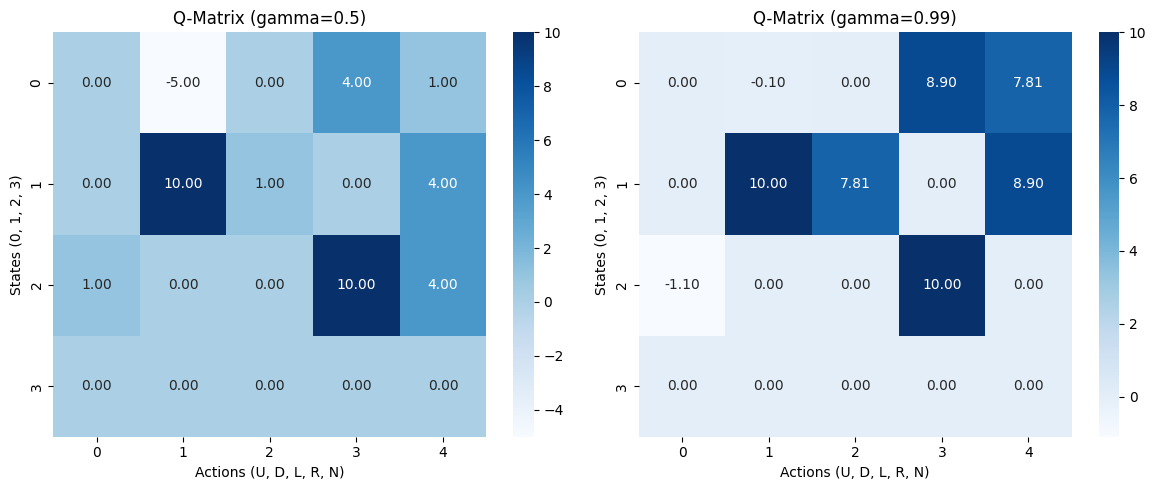

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Q-Learning 실행 함수
def q_learning(gamma, episodes=10):
    q_matrix = np.zeros((4, 5))
    for _ in range(episodes):
        current_state = 0
        while current_state != 3:
            action = random.choice(valid_action[current_state])
            next_state = transition_matrix[current_state][action]

            future_rewards = [
                q_matrix[next_state][action_nxt] for action_nxt in valid_action[next_state]
            ]
            q_state = reward[current_state][action] + gamma * max(future_rewards)

            q_matrix[current_state][action] = q_state
            current_state = next_state

    return q_matrix

gamma_values = [0.5, 0.99]
q_results = {gamma: q_learning(gamma) for gamma in gamma_values}

# Q-matrix 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (gamma, q_matrix) in zip(axes, q_results.items()):
    sns.heatmap(q_matrix, annot=True, fmt=".2f", cmap="Blues", ax=ax)
    ax.set_title(f"Q-Matrix (gamma={gamma})")
    ax.set_xlabel("Actions (U, D, L, R, N)")
    ax.set_ylabel("States (0, 1, 2, 3)")

plt.tight_layout()
plt.show()

### 🚀 Gamma 값 변화에 따른 Q-Matrix 비교

#### **1️⃣ Gamma (γ) 값의 의미**
- **Gamma (γ)** 는 **할인율 (Discount Factor)** 로, 
  미래 보상을 현재 가치로 변환하는 역할을 한다.
- **γ가 크면** → 미래 보상을 중요하게 고려 (장기적 최적화)
- **γ가 작으면** → 현재 보상을 더 중요하게 반영 (단기적 최적화)

---

#### **2️⃣ Q-Matrix 비교 결과**
| Gamma 값  | 학습 특성 | Q-Matrix 특징 |
|-----------|--------------------------|-----------------------------|
| **γ = 0.5 (단기적 학습)** | - **현재 보상 중심**으로 학습됨  | - 값이 빠르게 수렴함  |
| **γ = 0.99 (장기적 학습)** | - **미래 보상을 더 고려**하여 학습 | - Q-값이 높아지고, 더욱 최적화된 값으로 수렴 |

---

#### **3️⃣ 시각적 비교 분석**
##### **🔹 γ = 0.5 (좌측 그래프)**
- 보상이 **즉각적인 영향**을 주며, `Q-값`이 비교적 낮음.
- `state 1`과 `state 2`에서 보상에 의한 영향이 크지만,
  **장기적인 경로 학습은 부족함.**
- **보상이 10인 지점에서 빠르게 수렴**하며, 다른 값들은 상대적으로 낮음.

##### **🔹 γ = 0.99 (우측 그래프)**
- 보상을 **장기적인 관점**에서 학습하여, `Q-값`이 전반적으로 높아짐.
- `state 0`에서도 Q-값이 높아져, **장기적인 이동 최적화가 이루어짐.**
- `gamma=0.5`보다 **더 높은 Q-값을 가지며, 전체적으로 안정적인 학습 진행**.

---

#### **4️⃣ 결론**
- **단기 목표 최적화**가 필요하면 `γ = 0.5`를 사용.
- **장기 최적 경로 탐색**이 필요하면 `γ = 0.99`를 사용.
- **문제에 따라 적절한 γ 값을 선택하는 것이 중요!**